In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
import torch.nn.functional as F
from tqdm.auto import tqdm
import re
import pandas as pd
from spacy.cli import download
import matplotlib.pyplot as plt
import seaborn as sn
import numpy as np
import torch
import umap
from transformers import AutoTokenizer, AutoModel
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import spacy
import os
from IPython.display import display
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

file_path = '/kaggle/input/datasets/georgekurokijr/dl-2024/dadosTextosCientificos.tsv'
#TSV com encoding latin1
df = pd.read_csv(file_path, sep='\t', encoding='latin1')

In [27]:
#SpaCy
# Parte do que seria o "transfer learning"
try:
    nlp = spacy.load("pt_core_news_sm")
except:
    download("pt_core_news_sm")
    nlp = spacy.load("pt_core_news_sm")


# Palavras extremamente genéricas
termos_genericos = {

    "objetivo","objetivar","pesquisa","estudo","resultado","análise",
    "avaliar","avaliação","propor","proposta","desenvolver",
    "desenvolvimento","utilizar","uso","usar","método","metodologia",
    "modelo","dados","informação","processo",
    "solução","tecnologia","empresa","mercado",
    "trabalho","artigo","presente","respectivo",
    "principal","importante","novo","nova",
    "através","partir","forma","meio","realizar",
    "permitir","possuir","obter","identificar",
    "apresentar","aplicação","caracterização",
    "implementação","validação","teste","projeto",
    "base","contexto","fase","tipo","caso",
    "algum","alguma","outro","outra","energia","ser","visar",
    "produto","produção","produzir",
    "projeto", "sistema","equipamento",
    "resultado esperado","atividade","etapa","uso","utilização","aplicar",
    "possibilitar","através","baseado","basear","utilizado","utilizar","gerar",
    "obter","obtenção","industrial","indústria","produto","empresa",
    "contexto","principal","dado",
    "informações","material","imagem","trata","paciente"
}

siglas_tecnicas = {
    "fpso","rov","ifa","pig","ibr","api",
    "waam","olga","viv","cfd","fea","dns",
    "ia","cnn","lstm","gps","gis"
}

# Limpeza
def limpar_texto(texto):

    if not isinstance(texto,str):
        return ""
    texto = texto.lower()
    texto = re.sub(r"\d+"," ",texto)
    texto = re.sub(r"[%°ºª]"," ",texto)
    doc = nlp(texto)

    tokens=[]

    for token in doc:

        lemma=token.lemma_.lower()

        if token.is_stop:
            continue

        if token.is_punct:
            continue

        if token.like_num:
            continue

        if token.ent_type_=="PER":
            continue

        if lemma in termos_genericos:
            continue

        if len(lemma)<=2 and lemma not in siglas_tecnicas:
            continue

        if token.is_alpha:

            tokens.append(lemma)

    return " ".join(tokens)

coluna_texto=df.columns[1]
df["texto_limpo"]=df[coluna_texto].apply(limpar_texto)
display(df[["texto_limpo"]].head())

,texto_limpo
0,inovação tecnológico auxiliir sustentável serv...
1,inovação tecnológico auxiliir sustentável nece...
2,brasil considerar país biodiversidade mundo di...
3,brasil considerar país biodiversidade mundo di...
4,último ano comunidade científico despertar int...


In [28]:

# VOCABULÁRIO TÉCNICO ESPECIALIZADO
# Aproximadamente 200 radicais distribuídos por domínio
vocabulario_tecnico = {


# PETRÓLEO E RESERVATÓRIOS
"PETROLEO": [

"petrole","gas","reservat","carbonat","arenit","calcario",
"permeabil","poros","porosid","rocha","litolog","estratigraf",
"diagene","sediment","bacia","sism","perfil","perfilag",
"petrofis","plug","poço",
"pressur","inje","produc","recuper","secund",
"terciar","agua","salmoura","fluido","escoament",
"atur","matriz","campo","offshore","onshore",
"bloco","explor","perfura","sondag","lama","broca",
"complet","canhone","revest","cimento","ciment","clinker",
"anular","casing","liner","packer","tubing","wellhead"

],

# ENGENHARIA SUBMARINA
"SUBMARINO":[

"riser","flowline","jumper","manifold","umbilical",
"ancorag","amarr","moor","fpso","plsv","subsea",
"submarin","rov","auv","torpedo","flexiv",
"conector","spool","tree","christmas","wellhead",
"pig","pigging","pigador","hidrato","parafina",
"wax","slug","multifas","orcaflex","olga",
"viv","vortex","fadig","tension","topside",
"pipeline","tieback","deepwater","ultradeep",
"umbilic","pullin","lay","laying","hookup",
"pullout","instal","intervenc","ancora","guindaste"

],

# INTEGRIDADE E CORROSÃO
"Engenharia de Materiais":[

"corros","trinca","desgaste","eros","cavit",
"phased","array","inspec",
"anomali","pig","ibr","reparo",
"degrad","revest","coating",
"epoxi","catod","catodic","galvan",
"acust","vibrac","strain","stress","ruptura","espess","espessura",
"fissura","microtrinca","macrotrinca","oxida",
"ferrug","remanesc"

],

# AGRO
"AGRO":[

"agro","agric","bovin",
"pecuar","lavoura","colheit","agroneg",
"pastag","pasto","semear","suino","adub"

],

# METALURGIA
"METALURGIA":[

"aco","liga","niquel","cromo","molibden","titan",
"alumin","duplex","superduplex","inconel",
"hastelloy","metalurg","microestrut",
"ferrita","austenit","martens","perlita",
"cementita","termic","têmpera",
"reven","recoz","normaliz","dureza","tracao",
"tenacid","ductil",
"solda","waam","cladding",
"arame","arco","gmaw","gtaw","smaw","mig","tig",
"eletrodo","fusao","solidific"

],

# BIOCOMBUSTÍVEIS
"BIOENERGIA":[

"etanol","metanol","biodiesel","diesel","biogas",
"biomass","bagaco","palha",
"ferment","levedur","enzim","amilase",
"lignina","hemicelulose","celulose",
"hidrolis","destil","sacarose","glicose",
"xilose","frutose","alcool","biooleo",
"pirólis","pirólise","glicer","oleagin",
"combust","bioqueros","bioplastic","bioetanol"

],

# BIOMEDICINA
"BIOMEDICINA":[

"coronavir","influenza","bacter","médico",
"parasit","leucem","tumor","cancer",
"oncolog","anticorpo","antigen","ifa",
"ensaio","placebo","imun","anticancer","patogen",
"sorolog","gene","dna","rna","enzim"

],


# INTELIGÊNCIA ARTIFICIAL
"IA":[

"machine","learning",
"deep","rede neural","cnn","rnn",
"lstm","bert","embedding",
"cluster","regress","random forest",
"xgboost","svm","bayes","knn",
"autoencoder","pca","umap","tsne",
"token","nlp",

],

# AUTOMAÇÃO E SENSORIAMENTO
"IOT":[

"iot","software embarcado","arduino","raspberry",
"pid","supervisor","scada",
"plc","clp","nivel","atuador","encoder","servo",
"robot","laser","radar","gps",
"gis","fibra","optica","wireless",
"bluetooth","wifi","zigbee","mqtt"

]

}

total = sum(len(v) for v in vocabulario_tecnico.values())

print("="*60)
print("VOCABULÁRIO TÉCNICO CARREGADO")
print("="*60)

for area, palavras in vocabulario_tecnico.items():
    print(f"{area:15} -> {len(palavras):3d} radicais")

print("-"*60)
print(f"TOTAL DE RADICAIS: {total}")
print("="*60)

VOCABULÁRIO TÉCNICO CARREGADO
PETROLEO        ->  54 radicais
SUBMARINO       ->  50 radicais
Engenharia de Materiais ->  32 radicais
AGRO            ->  12 radicais
METALURGIA      ->  40 radicais
BIOENERGIA      ->  31 radicais
BIOMEDICINA     ->  22 radicais
IA              ->  22 radicais
IOT             ->  25 radicais
------------------------------------------------------------
TOTAL DE RADICAIS: 288


In [29]:

# Engenharia de Features Técnicas
# lista única com todos os radicais
lista_radicais = []

for palavras in vocabulario_tecnico.values():
    lista_radicais.extend(palavras)

lista_radicais = list(dict.fromkeys(lista_radicais))
print(f"Radicais técnicos únicos: {len(lista_radicais)}")

# frequência de cada radical
def vetor_tecnico(texto):

    texto = texto.lower()
    vetor = []
    for radical in lista_radicais:

        ocorrencias = len(
            re.findall(
                rf"\b{re.escape(radical)}\w*",
                texto
            )
        )

        vetor.append(ocorrencias)
    return vetor


X_tecnico = np.array(

    df["texto_limpo"].apply(vetor_tecnico).tolist()

)

print("\nShape da matriz técnica:")
print(X_tecnico.shape)

df_features = pd.DataFrame(
    X_tecnico,
    columns=lista_radicais

)

display(df_features.head())

Radicais técnicos únicos: 284

Shape da matriz técnica:
(2725, 284)


,petrole,gas,reservat,carbonat,arenit,calcario,permeabil,poros,porosid,rocha,...,radar,gps,gis,fibra,optica,wireless,bluetooth,wifi,zigbee,mqtt
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,2,0,0,0,0,0,0


In [30]:
# TF-IDF
print("="*60)
print("GERANDO MATRIZ TF-IDF")
print("="*60)

tfidf = TfidfVectorizer(

    lowercase=True,
    # unigramas e bigramas
    ngram_range=(1,2),
    max_features=5000,
    # elimina palavras muito raras
    min_df=3,
    # elimina palavras extremamente frequentes
    max_df=0.85,
    sublinear_tf=True,
    norm="l2"

)

X_tfidf = tfidf.fit_transform(df["texto_limpo"])
nomes_termos = np.array(
    tfidf.get_feature_names_out()
)

print(f"Número de documentos : {X_tfidf.shape[0]}")
print(f"Número de features    : {X_tfidf.shape[1]}")
print("\nExemplo de termos:")
print(nomes_termos[:30])

GERANDO MATRIZ TF-IDF
Número de documentos : 2725
Número de features    : 4228

Exemplo de termos:
['abaixo' 'abastecimento' 'abertura' 'abiótico' 'abnt' 'abnt em'
 'abordagem' 'abordar' 'abrangente' 'abranger' 'abranger eletrônica'
 'abrasivo' 'abrasivo ferro' 'abrir' 'absorver' 'absorção' 'abundante'
 'acabamento' 'acabar' 'acarretar' 'aceitável' 'acelerador' 'acelerar'
 'acesso' 'acesso remoto' 'acesso veículo' 'acessível' 'acessório'
 'acidente' 'acidez']


In [31]:
# Embeddings Bertimbau
print("="*60)
print("CARREGANDO BERTIMBAU")
print("="*60)

modelo = "neuralmind/bert-base-portuguese-cased"
tokenizer = AutoTokenizer.from_pretrained(modelo)
bert = AutoModel.from_pretrained(modelo)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert.to(device)
bert.eval()

print(f"Dispositivo utilizado: {device}")

def mean_pooling(model_output, attention_mask):

    token_embeddings = model_output.last_hidden_state

    input_mask_expanded = (
        attention_mask
        .unsqueeze(-1)
        .expand(token_embeddings.size())
        .float()
    )

    soma = torch.sum(token_embeddings * input_mask_expanded, 1)
    divisor = torch.clamp(
        input_mask_expanded.sum(1),
        min=1e-9
    )

    return soma / divisor

CARREGANDO BERTIMBAU


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Dispositivo utilizado: cuda


In [32]:
batch_size = 16
embeddings = []
textos = df["texto_limpo"].tolist()

with torch.no_grad():

    for i in tqdm(range(0, len(textos), batch_size)):

        lote = textos[i:i+batch_size]

        entradas = tokenizer(
            lote,
            padding=True,
            truncation=True,
            max_length=256,
            return_tensors="pt"

        )

        entradas = {
            k:v.to(device)
            for k,v in entradas.items()

        }

        saida = bert(**entradas)
        vetor = mean_pooling(
            saida,
            entradas["attention_mask"]

        )

        vetor = F.normalize(vetor, p=2, dim=1)
        embeddings.append(
            vetor.cpu().numpy()

        )

X_bert = np.vstack(embeddings)
print("\nEmbeddings gerados com sucesso!")
print(X_bert.shape)

  0%|          | 0/171 [00:00<?, ?it/s]


Embeddings gerados com sucesso!
(2725, 768)


In [33]:
# UMAP para Clusterização
print("="*70)
print("FUSÃO DAS FEATURES")
print("="*70)

svd_tfidf = TruncatedSVD(
    n_components=150,
    random_state=42
)

X_tfidf_red = svd_tfidf.fit_transform(X_tfidf)
print(f"Variância TF-IDF: {svd_tfidf.explained_variance_ratio_.sum():.2%}")


# Redução das Features Técnicas
print("="*70)

n_comp_tecnico = min(60, X_tecnico.shape[1]-1)

svd_tecnico = TruncatedSVD(
    n_components=n_comp_tecnico,
    random_state=42
)

X_tecnico_red = svd_tecnico.fit_transform(X_tecnico)
print(f"Variância Técnica: {svd_tecnico.explained_variance_ratio_.sum():.2%}")


X_bert_std = StandardScaler().fit_transform(X_bert)
X_tfidf_std = StandardScaler().fit_transform(X_tfidf_red)
X_tecnico_std = StandardScaler().fit_transform(X_tecnico_red)

# O BERT possui 768 dimensões.
# Mesmo reduzindo TF-IDF ele ainda tende a dominar.
# Por isso damos mais importância ao conhecimento técnico.
peso_bert = 0.55
peso_tfidf = 1.20
peso_tecnico = 2.30

X_fusion = np.hstack([
    X_bert_std * peso_bert,
    X_tfidf_std * peso_tfidf,
    X_tecnico_std * peso_tecnico

])

X_fusion = StandardScaler().fit_transform(X_fusion)
print("\nShape após Feature Fusion")
print(X_fusion.shape)
print("="*70)
print("\nReduzindo espaço para Clusterização...")

umap_cluster = umap.UMAP(
    n_components=30,
    metric="cosine",
    n_neighbors=20,
    min_dist=0.05,
    random_state=42

)

X_cluster = umap_cluster.fit_transform(X_fusion)
print("\nShape Final para Clusterização")
print(X_cluster.shape)

FUSÃO DAS FEATURES
Variância TF-IDF: 29.82%
Variância Técnica: 91.25%

Shape após Feature Fusion
(2725, 978)

Reduzindo espaço para Clusterização...

Shape Final para Clusterização
(2725, 30)


In [34]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

intervalo_k = range(5,11)
resultados = []

for k in intervalo_k:

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=40

    )

    labels = modelo.fit_predict(X_cluster)
    sil = silhouette_score(X_cluster, labels)
    db = davies_bouldin_score(X_cluster, labels)
    ch = calinski_harabasz_score(X_cluster, labels)

    resultados.append({

        "K":k,
        "Silhouette":sil,
        "Davies":db,
        "Calinski":ch
    })

metricas = pd.DataFrame(resultados)
display(metricas)

# Ranking das métricas
metricas["Rank_Sil"] = metricas["Silhouette"].rank(
    ascending=False,
    method="min"
)

metricas["Rank_DB"] = metricas["Davies"].rank(
    ascending=True,
    method="min"
)

metricas["Rank_CH"] = metricas["Calinski"].rank(
    ascending=False,
    method="min"
)

metricas["Score_Final"] = (
    metricas["Rank_Sil"]

    +
    metricas["Rank_DB"]

    +
    metricas["Rank_CH"]

)

display(

    metricas.sort_values("Score_Final")

)

# Melhor K
melhor_k = int(
    metricas.sort_values(
        "Score_Final"
    ).iloc[0]["K"]

)

,K,Silhouette,Davies,Calinski
0,5,0.346939,1.064921,1954.667969
1,6,0.346606,1.092749,1920.641968
2,7,0.352002,1.015856,1855.587036
3,8,0.367872,0.964251,1867.681274
4,9,0.349354,0.993160,1880.030884
5,10,0.344216,1.009815,1858.451660


,K,Silhouette,Davies,Calinski,Rank_Sil,Rank_DB,Rank_CH,Score_Final
3,8,0.367872,0.964251,1867.681274,1.0,1.0,4.0,6.0
4,9,0.349354,0.993160,1880.030884,3.0,2.0,3.0,8.0
0,5,0.346939,1.064921,1954.667969,4.0,5.0,1.0,10.0
2,7,0.352002,1.015856,1855.587036,2.0,4.0,6.0,12.0
1,6,0.346606,1.092749,1920.641968,5.0,6.0,2.0,13.0
5,10,0.344216,1.009815,1858.451660,6.0,3.0,5.0,14.0


In [35]:
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# Escolha Automática do Melhor Algoritmo
print("="*80)
print("COMPARANDO KMEANS E AGGLOMERATIVE")
print("="*80)

algoritmos = {
    "KMeans": KMeans,
    "Agglomerative": AgglomerativeClustering

}
resultados = []

# Cada algoritmo procura seu melhor K
for nome, algoritmo in algoritmos.items():
    for k in range(5,11):
        if nome=="KMeans":
            modelo = algoritmo(
                n_clusters=k,
                random_state=42,
                n_init=40

            )

        else:
            modelo = algoritmo(
                n_clusters=k,
                linkage="ward"

            )

        labels = modelo.fit_predict(X_cluster)
        sil = silhouette_score(X_cluster, labels)
        db = davies_bouldin_score(X_cluster, labels)
        ch = calinski_harabasz_score(X_cluster, labels)
        resultados.append({

            "Algoritmo":nome,
            "K":k,
            "Silhouette":sil,
            "Davies":db,
            "Calinski":ch

        })
comparacao = pd.DataFrame(resultados)

# Ranking
comparacao["Rank_Sil"] = comparacao["Silhouette"].rank(
    ascending=False,
    method="min"

)

comparacao["Rank_DB"] = comparacao["Davies"].rank(
    ascending=True,
    method="min"

)

comparacao["Rank_CH"] = comparacao["Calinski"].rank(
    ascending=False,
    method="min"

)

comparacao["Score"] = (
    comparacao["Rank_Sil"]

    +
    comparacao["Rank_DB"]

    +
    comparacao["Rank_CH"]

)
comparacao = comparacao.sort_values("Score")
display(comparacao.head(15))


# Melhor Resultado
melhor = comparacao.iloc[0]
melhor_algoritmo = melhor["Algoritmo"]
melhor_k = int(melhor["K"])
print("="*80)
print("MELHOR CONFIGURAÇÃO")
print("="*80)
print(f"Algoritmo : {melhor_algoritmo}")
print(f"K : {melhor_k}")


# Treino do melhor modelo
if melhor_algoritmo=="KMeans":
    melhor_modelo = KMeans(
        n_clusters=melhor_k,
        random_state=42,
        n_init=40

    )

else:
    melhor_modelo = AgglomerativeClustering(
        n_clusters=melhor_k,
        linkage="ward"

    )

df["cluster"] = melhor_modelo.fit_predict(X_cluster)
print("\nDistribuição dos clusters\n")
display(
    df["cluster"]
    .value_counts()
    .sort_index()

)

COMPARANDO KMEANS E AGGLOMERATIVE


,Algoritmo,K,Silhouette,Davies,Calinski,Rank_Sil,Rank_DB,Rank_CH,Score
3,KMeans,8,0.367872,0.964251,1867.681274,1.0,1.0,4.0,6.0
4,KMeans,9,0.349354,0.993160,1880.030884,3.0,2.0,3.0,8.0
2,KMeans,7,0.352002,1.015856,1855.587036,2.0,5.0,6.0,13.0
0,KMeans,5,0.346939,1.064921,1954.667969,4.0,8.0,1.0,13.0
5,KMeans,10,0.344216,1.009815,1858.451660,6.0,4.0,5.0,15.0
1,KMeans,6,0.346606,1.092749,1920.641968,5.0,9.0,2.0,16.0
9,Agglomerative,8,0.339099,0.999419,1668.547119,7.0,3.0,8.0,18.0
8,Agglomerative,7,0.326208,1.056302,1677.362183,8.0,7.0,7.0,22.0
10,Agglomerative,9,0.315449,1.045917,1642.065552,10.0,6.0,10.0,26.0
11,Agglomerative,10,0.319111,1.093796,1632.367676,9.0,10.0,11.0,30.0


MELHOR CONFIGURAÇÃO
Algoritmo : KMeans
K : 8

Distribuição dos clusters



cluster
0    660
1    377
2    472
3    266
4    138
5    246
6    275
7    291
Name: count, dtype: int64

In [36]:
print("="*80)
print("IDENTIFICANDO OS TEMAS DOS CLUSTERS")
print("="*80)

# Identificação Automática dos Temas
# Nomes das features do TF-IDF
nomes_features = np.array(tfidf.get_feature_names_out())

nomes_clusters = {}
termos_clusters = {}

for cluster in sorted(df["cluster"].unique()):
    mascara = (df["cluster"] == cluster).to_numpy()
    matriz_cluster = X_tfidf[mascara]

    # Média dos pesos TF-IDF
    pesos = np.asarray(
        matriz_cluster.mean(axis=0)
    ).ravel()
    ordem = np.argsort(pesos)[::-1]
    # principais termos
    top200 = nomes_features[ordem[:50]]
    termos_clusters[cluster] = top200

    # domínio técnico predominante
    pontuacoes = {}
    for area, radicais in vocabulario_tecnico.items():
        score = 0
        for termo in top200:
            if any(termo.startswith(rad) for rad in radicais):
                score += 1
        pontuacoes[area] = score

    # Melhor domínio
    melhor_area = max(
        pontuacoes,
        key=pontuacoes.get
    )

    # Caso nenhum radical tenha aparecido
    if pontuacoes[melhor_area] == 0:
        nome = "Tema Geral"

    else:
        nome = melhor_area.replace("_", " ").title()
    nomes_clusters[cluster] = nome


    print("\n" + "="*80)
    print(f"Cluster {cluster}")
    print(f"Tema identificado: {nome}")
    print(f"Documentos: {mascara.sum()}")
    print("\nTop 20 termos:")
    print(", ".join(top200[:40]))
    print("\nPontuação dos domínios:")

    ranking = sorted(
        pontuacoes.items(),
        key=lambda x: x[1],
        reverse=True
    )

    for area, score in ranking[:5]:
        print(f"{area:40s} {score}")

IDENTIFICANDO OS TEMAS DOS CLUSTERS

Cluster 0
Tema identificado: Iot
Documentos: 660

Top 20 termos:
software, plataforma, dispositivo, monitoramento, comunicação, hardware, embarcar, inteligente, inteligência, controle, inteligência artificial, gerenciamento, rede, artificial, módulo, iot, remoto, automação, integrar, gestão, integração, suporte, óptico, móvel, plataforma software, sensor, software embarcar, máquina, nuvem, capaz, automatizar, firmware, sensoriamento, interface, conectividade, eletrônico, serviço, software gerenciamento, funcionalidade, automático

Pontuação dos domínios:
IOT                                      1
PETROLEO                                 0
SUBMARINO                                0
Engenharia de Materiais                  0
AGRO                                     0

Cluster 1
Tema identificado: Bioenergia
Documentos: 377

Top 20 termos:
resíduo, rota, rota tecnológico, polimérico, tecnológico, formulação, biomassa, rejeito, minério, escala, recupera

In [37]:
# UMAP para Visualização
# Redução para visualização
umap_visual = umap.UMAP(

    n_components=2,
    n_neighbors=25,
    min_dist=0.15,
    metric="euclidean",
    random_state=42

)
X_umap = umap_visual.fit_transform(X_cluster)


# coordenadas
df["umap_x"] = X_umap[:,0]
df["umap_y"] = X_umap[:,1]

#  visual dos clusters
# (mediana funciona melhor que média)
centros_clusters = {}
for cluster in sorted(df["cluster"].unique()):

    grupo = df[df["cluster"] == cluster]
    centros_clusters[cluster] = {

        "x": grupo["umap_x"].median(),
        "y": grupo["umap_y"].median(),
        "n": len(grupo)

    }

print("\nResumo dos clusters\n")

for cluster in sorted(centros_clusters):

    print(

        f"Cluster {cluster:2d}"
        f" | {nomes_clusters[cluster]:35s}"
        f" | {centros_clusters[cluster]['n']} documentos"

    )



Resumo dos clusters

Cluster  0 | Iot                                 | 660 documentos
Cluster  1 | Bioenergia                          | 377 documentos
Cluster  2 | Ia                                  | 472 documentos
Cluster  3 | Biomedicina                         | 266 documentos
Cluster  4 | Agro                                | 138 documentos
Cluster  5 | Agro                                | 246 documentos
Cluster  6 | Engenharia De Materiais             | 275 documentos
Cluster  7 | Tema Geral                          | 291 documentos


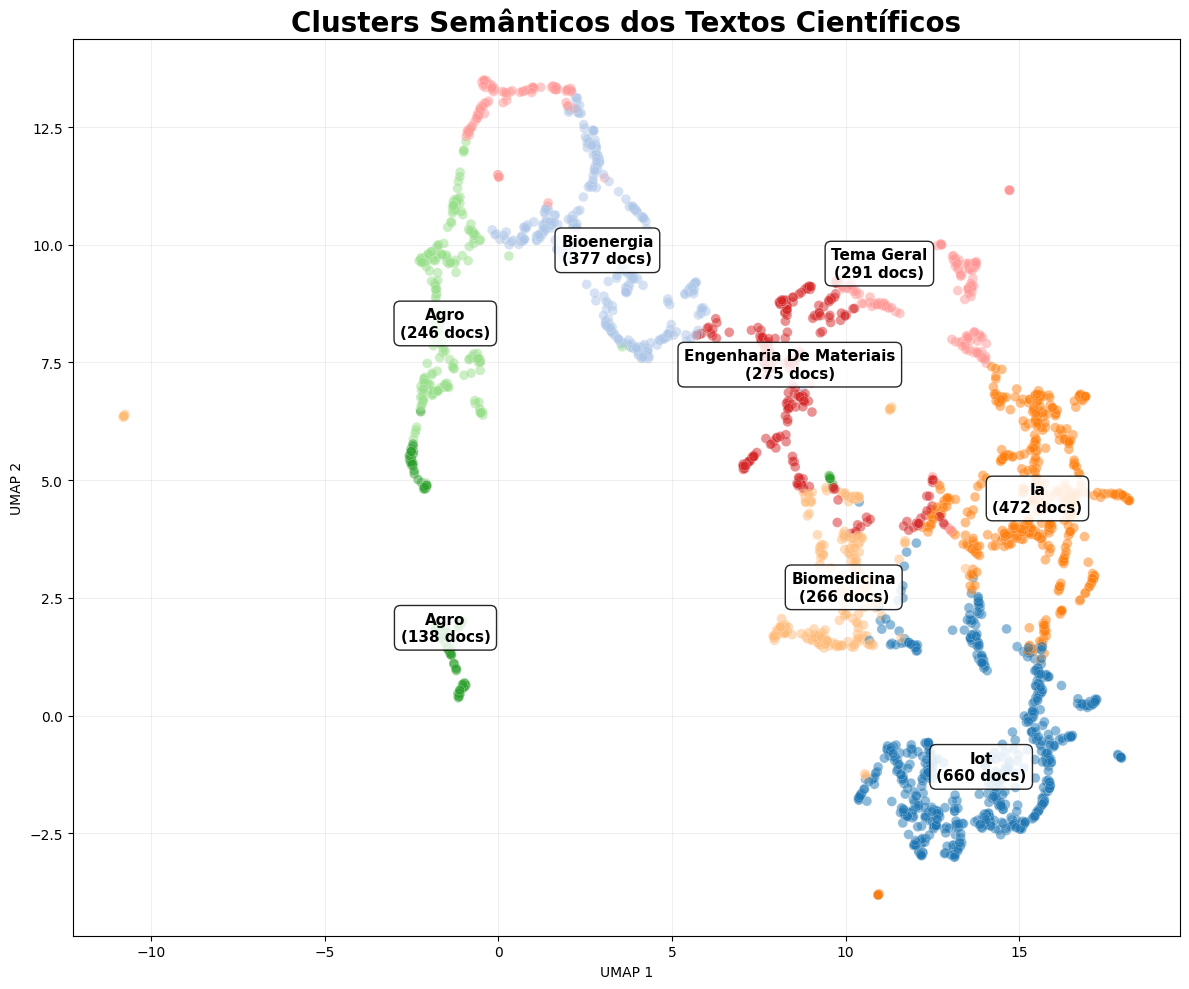

In [38]:
plt.figure(figsize=(12,10))

cores = sns.color_palette("tab20", len(df["cluster"].unique()))

ax = sns.scatterplot(

    data=df,
    x="umap_x",
    y="umap_y",
    hue="cluster",
    palette=cores,
    s=50,
    alpha=0.50,
    edgecolor="white",
    linewidth=0.25,
    legend=False

)

# Nome dos clusters
for cluster in sorted(df["cluster"].unique()):
    grupo = df[df["cluster"] == cluster]
    x = grupo["umap_x"].median()
    y = grupo["umap_y"].median()

    plt.annotate(

        f"{nomes_clusters[cluster]}\n({len(grupo)} docs)",

        (x, y),
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="center",
        bbox=dict(

            facecolor="white",
            edgecolor="black",
            alpha=0.85,
            boxstyle="round,pad=0.4"

        )

    )

plt.title(

    "Clusters Semânticos dos Textos Científicos",
    fontsize=20,
    fontweight="bold"

)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(alpha=0.20)
plt.tight_layout()
plt.show()